<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%A0%D0%B5%D0%BA%D1%83%D1%80%D1%80%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B5_%D0%B8_%D0%BE%D0%B4%D0%BD%D0%BE%D0%BC%D0%B5%D1%80%D0%BD%D1%8B%D0%B5_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_%7C_%D0%94%D0%97_Lite_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Из ноутбуков по практике "Рекуррентные и одномерные сверточные нейронные сети" выберите лучшую сеть, либо создайте свою.
2. Запустите раздел "Подготовка"
3. Подготовьте датасет с параметрами `VOCAB_SIZE=20'000`, `WIN_SIZE=1000`, `WIN_HOP=100`, как в ноутбуке занятия, и обучите выбранную сеть. Параметры обучения можно взять из практического занятия. Для  всех обучаемых сетей в данной работе они должны быть одни и теже.
4. Поменяйте размер словаря tokenaizera (`VOCAB_SIZE`) на `5000`, `10000`, `40000`.  Пересоздайте датасеты, при этом оставьте `WIN_SIZE=1000`, `WIN_HOP=100`.
Обучите выбранную нейронку на этих датасетах.  Сделайте выводы об  изменении  точности распознавания авторов текстов. Результаты сведите в таблицу
5. Поменяйте длину отрезка текста и шаг окна разбиения текста на векторы  (`WIN_SIZE`, `WIN_HOP`) используя значения (`500`,`50`) и (`2000`,`200`). Пересоздайте датасеты, при этом оставьте `VOCAB_SIZE=20000`. Обучите выбранную нейронку на этих датасетах. Сделайте выводы об  изменении точности распознавания авторов текстов.

Результаты всей работы сведите в таблицу.

## Подготовка

In [2]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display
import pandas as pd

%matplotlib inline

In [3]:
# Загрузим датасет из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [4]:
# Распакуем архив в папку writers
!unzip -o writers.zip -d writers/


Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  


In [5]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [6]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Получим списка файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    # Выделяем имя класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатываем
    if m:

        # Получим имя класса
        class_name = m[1]

        # Получим имя выборки
        subset_name = m[2].lower()

        # Проверим тип выборки
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатываем
        if is_train or is_test:

            # Добавляем новый класс, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)

                # Инициализируем соответствующих классу строки текста
                text_train.append('')
                text_test.append('')

            # Найдем индекс класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')

            # Откроем файл на чтение
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:

                # Загрузим содержимого файла в строку
                text = f.read()
            # Определим выборку, куда будет добавлено содержимое
            subset = text_train if is_train else text_test

            # Добавим текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

Добавление класса "Булгаков"
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка.
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление файла "(Клиффорд_Саймак) Тес

In [7]:
# Определим количество классов
CLASS_COUNT = len(CLASS_LIST)

In [8]:
# Выведем прочитанные классы текстов
print(CLASS_LIST)

['Булгаков', 'Клиффорд_Саймак', 'Макс Фрай', 'Рэй Брэдберри', 'О. Генри', 'Стругацкие']


In [9]:
# Посчитаем количество текстов в обучающей выборке
print(len(text_train))

6


In [10]:
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):                   # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')           # Выведем имя класса
    print(f'  train: {text_train[cls][:200]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls][:200]}')    # Выведем фрагмент тестовой выборки
    print()

Класс: Булгаков
  train:  ﻿Белая гвардия   Посвящается[1]  Любови Евгеньевне Белозерской[2]  Пошел мелкий снег и вдруг повалил хло-  пьями. Ветер завыл; сделалась метель.  В одно мгновение темное небо смешалось с  снежным мор
  test :  ﻿Дон Кихот ДЕЙСТВУЮЩИЕ ЛИЦА Алонсо Кихано, он же Дон Кихот Ламанчский.  Антония – его племянница.  Ключница Дон Кихота.  Санчо Панса – оруженосец Дон Кихота.  Перо Перес – деревенский священник, лице

Класс: Клиффорд_Саймак
  train:  ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Этакая тяжелая громадина с прицепом, и неслась она во весь дух. Шоссе здесь срезает угол городка, и
  test :  ﻿Зачарованное паломничество    1  Гоблин со стропил следил за прячущимся монахом, который шпионил за ученым. Гоблин ненавидел монаха и имел для этого все основания. Монах никого не ненавидел и не люб

Класс: Макс Фрай
  train:  ﻿Власть несбывшегося   – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне

In [11]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with

class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

## Решение

In [12]:
# ваше решение

# ваше решение
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE   = 1000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 100                          # Шаг окна разбиения текста на векторы

stat = {'Title': [], 'VOCAB_SIZE': [VOCAB_SIZE], 'WIN_SIZE': [WIN_SIZE], 'WIN_HOP': [WIN_HOP], 'avg_accuracy': []}
tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

# Построение частотного словаря по обучающим текстам
tokenizer.fit_on_texts(text_train)
# Построение словаря в виде пар слово - индекс
items = list(tokenizer.word_index.items())
# Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)



In [13]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [utils.to_categorical(cls, class_count)] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

In [14]:
 # Формирование обучающей выборки
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
# Формирование тестовой выборки
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

# Проверка формы сформированных данных
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


In [15]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=50,
                        batch_size=128,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Вывод схемы модели
    display(plot_model(model, dpi=60, show_shapes=True))

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true,
               class_labels=[],
               cm_round=3,
               title='',
               figsize=(10, 10)):
    global stat
    # Вычисление предсказания сети
    y_pred = model.predict(x)
    # Построение матрицы ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, cm_round)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Нейросеть {title}: матрица ошибок нормализованная', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Стирание ненужной цветовой шкалы
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси при необходимости
    plt.show()

    print('-'*100)
    print(f'Нейросеть: {title}')

    # Для каждого класса:
    for cls in range(len(class_labels)):
        # Определяется индекс класса с максимальным значением предсказания (уверенности)
        cls_pred = np.argmax(cm[cls])
        # Формируется сообщение о верности или неверности предсказания
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        # Выводится текстовая информация о предсказанном классе и значении уверенности
        print('Класс: {:<20} {:3.0f}% сеть отнесла к классу {:<20} - {}'.format(class_labels[cls],
                                                                               100. * cm[cls, cls_pred],
                                                                               class_labels[cls_pred],
                                                                               msg))

    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))
    stat['avg_accuracy'].append(100. * cm.diagonal().mean())
    stat['Title'].append(title)


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=50,
                             batch_size=128,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

In [16]:
model = Sequential()
model.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
model.add(SpatialDropout1D(0.4))
model.add(BatchNormalization())
# Два двунаправленных рекуррентных слоя LSTM
model.add(Bidirectional(LSTM(8, return_sequences=True)))
model.add(Bidirectional(LSTM(8, return_sequences=True)))
model.add(Dropout(0.3))
model.add(BatchNormalization())
# Два рекуррентных слоя GRU
model.add(GRU(16, return_sequences=True, reset_after=True))
model.add(GRU(16, reset_after=True))
model.add(Dropout(0.3))
model.add(BatchNormalization())
# Дополнительный полносвязный слой
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Dense(CLASS_COUNT, activation='softmax'))
model.build()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

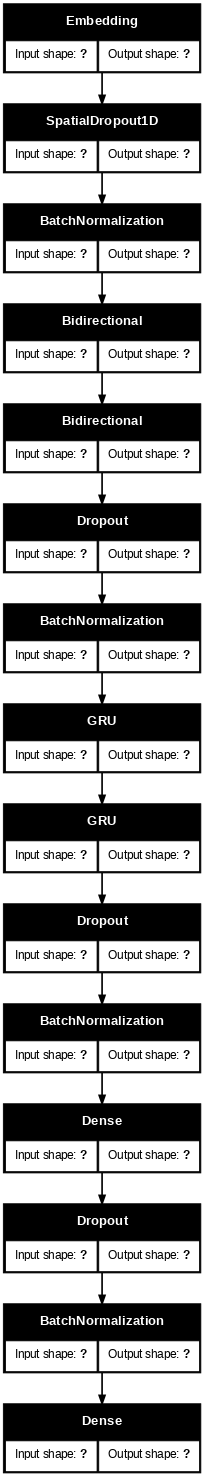

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 293ms/step - accuracy: 0.2102 - loss: 2.1326 - val_accuracy: 0.2929 - val_loss: 1.7433
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 272ms/step - accuracy: 0.3254 - loss: 1.7717 - val_accuracy: 0.2929 - val_loss: 1.7461
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 289ms/step - accuracy: 0.4151 - loss: 1.5101 - val_accuracy: 0.1611 - val_loss: 1.8156
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 266ms/step - accuracy: 0.4844 - loss: 1.2786 - val_accuracy: 0.2899 - val_loss: 1.7502
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - accuracy: 0.5520 - loss: 1.1097 - val_accuracy: 0.3439 - val_loss: 1.6593
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.5912 - loss: 1.0427 - val_accuracy: 0.3183 - val_loss: 1.6804
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.6251 - loss: 0.9350 - val_accuracy: 0.2501 - val_loss: 2.0633
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.6991 - loss: 0.7463 - va

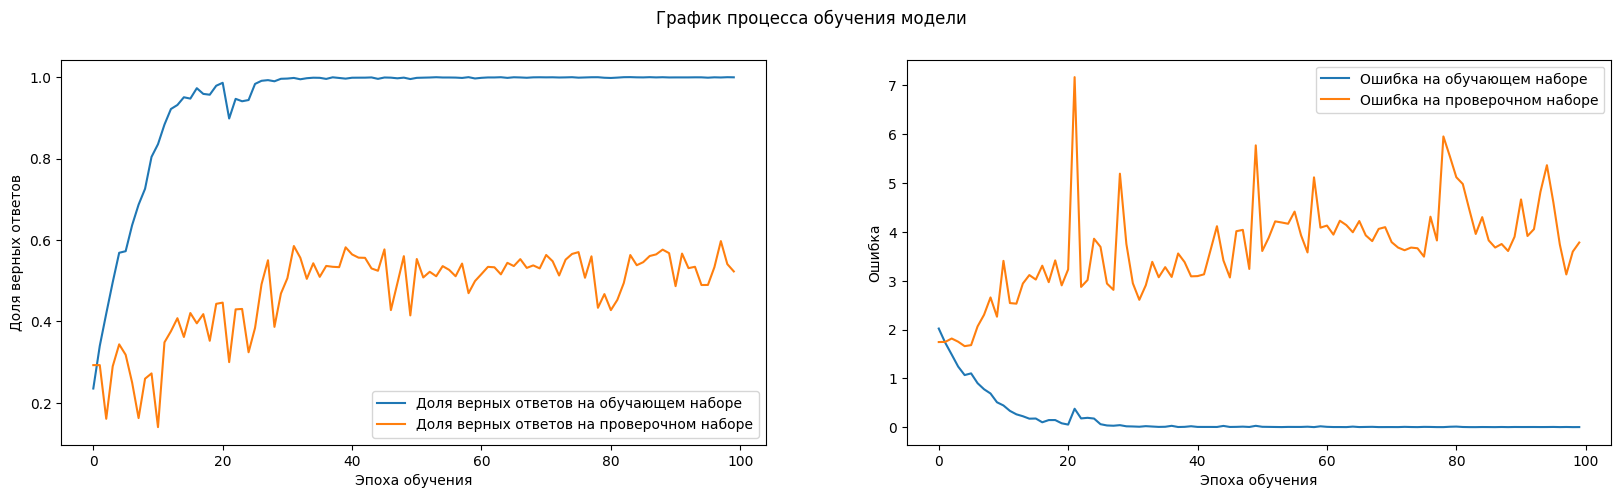

209/209 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step


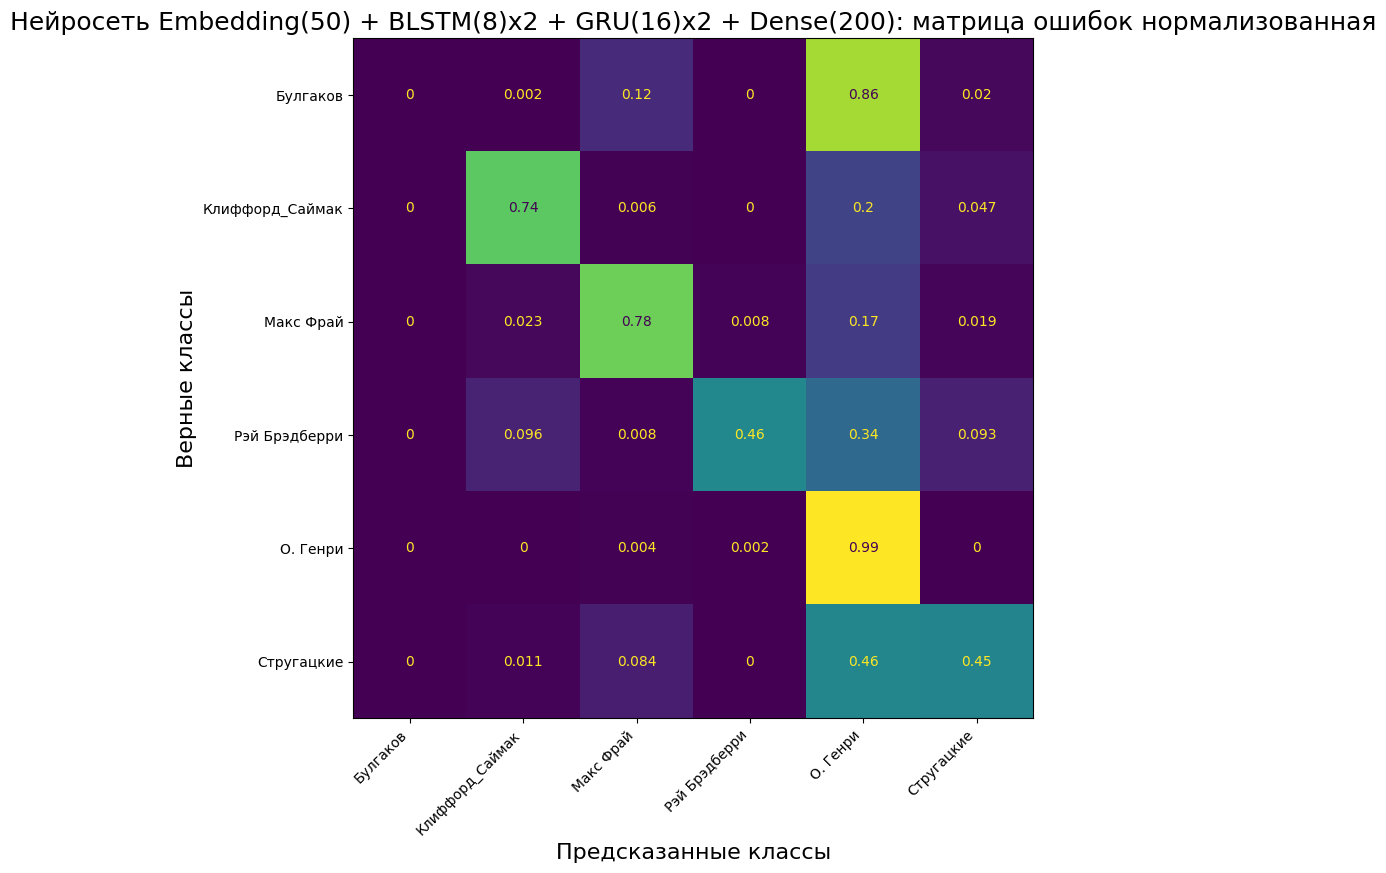

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)
Класс: Булгаков              86% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       74% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             78% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         46% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: О. Генри              99% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Стругацкие            46% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(

Средняя точность распознавания:  57%


In [17]:
compile_train_eval_model(model,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)')

(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_1                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

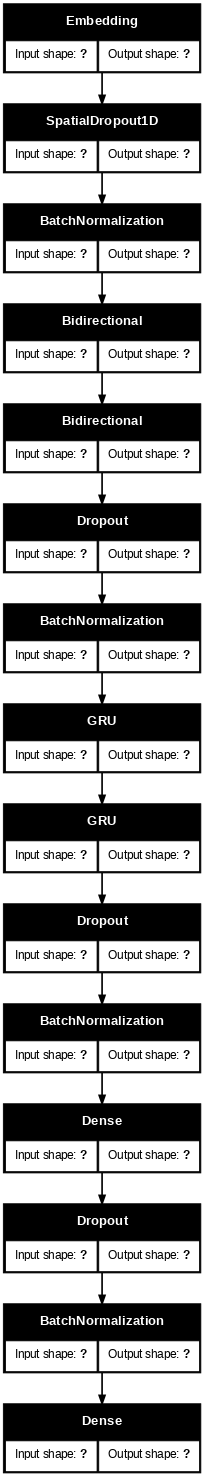

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 302ms/step - accuracy: 0.1986 - loss: 2.1690 - val_accuracy: 0.2929 - val_loss: 1.7417
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 313ms/step - accuracy: 0.2874 - loss: 1.8336 - val_accuracy: 0.2929 - val_loss: 1.7448
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 268ms/step - accuracy: 0.3560 - loss: 1.6742 - val_accuracy: 0.2945 - val_loss: 1.7598
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - accuracy: 0.4269 - loss: 1.4887 - val_accuracy: 0.1609 - val_loss: 1.8012
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step - accuracy: 0.5005 - loss: 1.3014 - val_accuracy: 0.1669 - val_loss: 1.8298
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.5724 - loss: 1.1114 - val_accuracy: 0.2094 - val_loss: 1.8655
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.6408 - loss: 0.9281 - val_accuracy: 0.3401 - val_loss: 1.5372
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.7029 - loss: 0.7722 - 

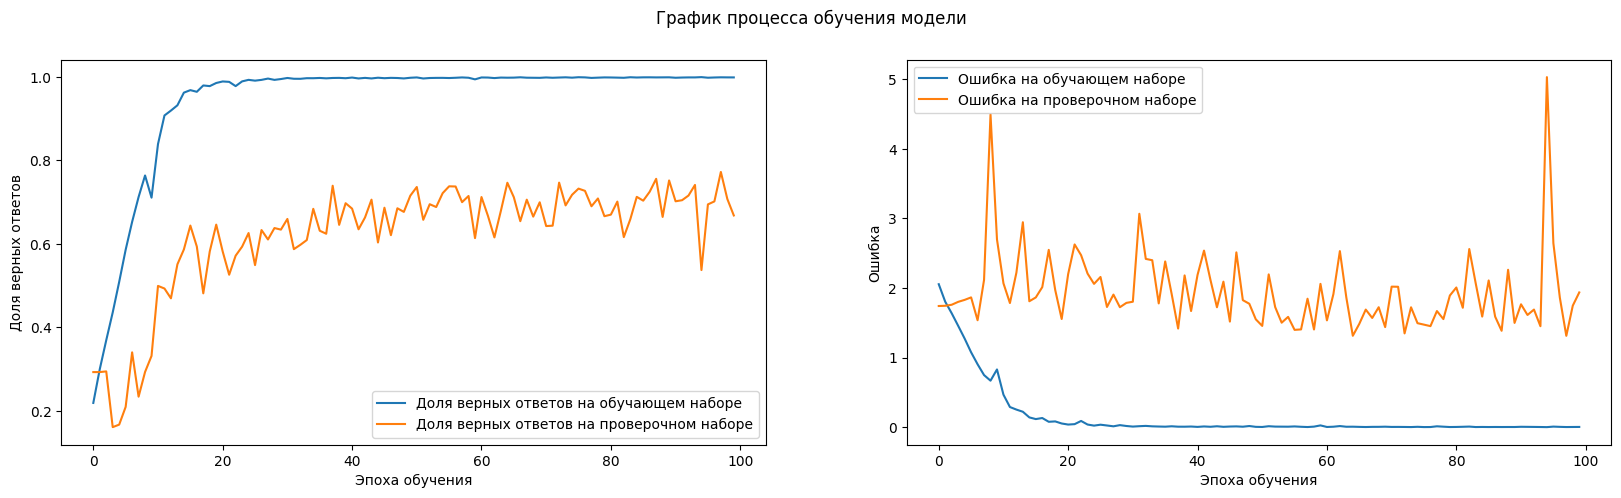

209/209 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step


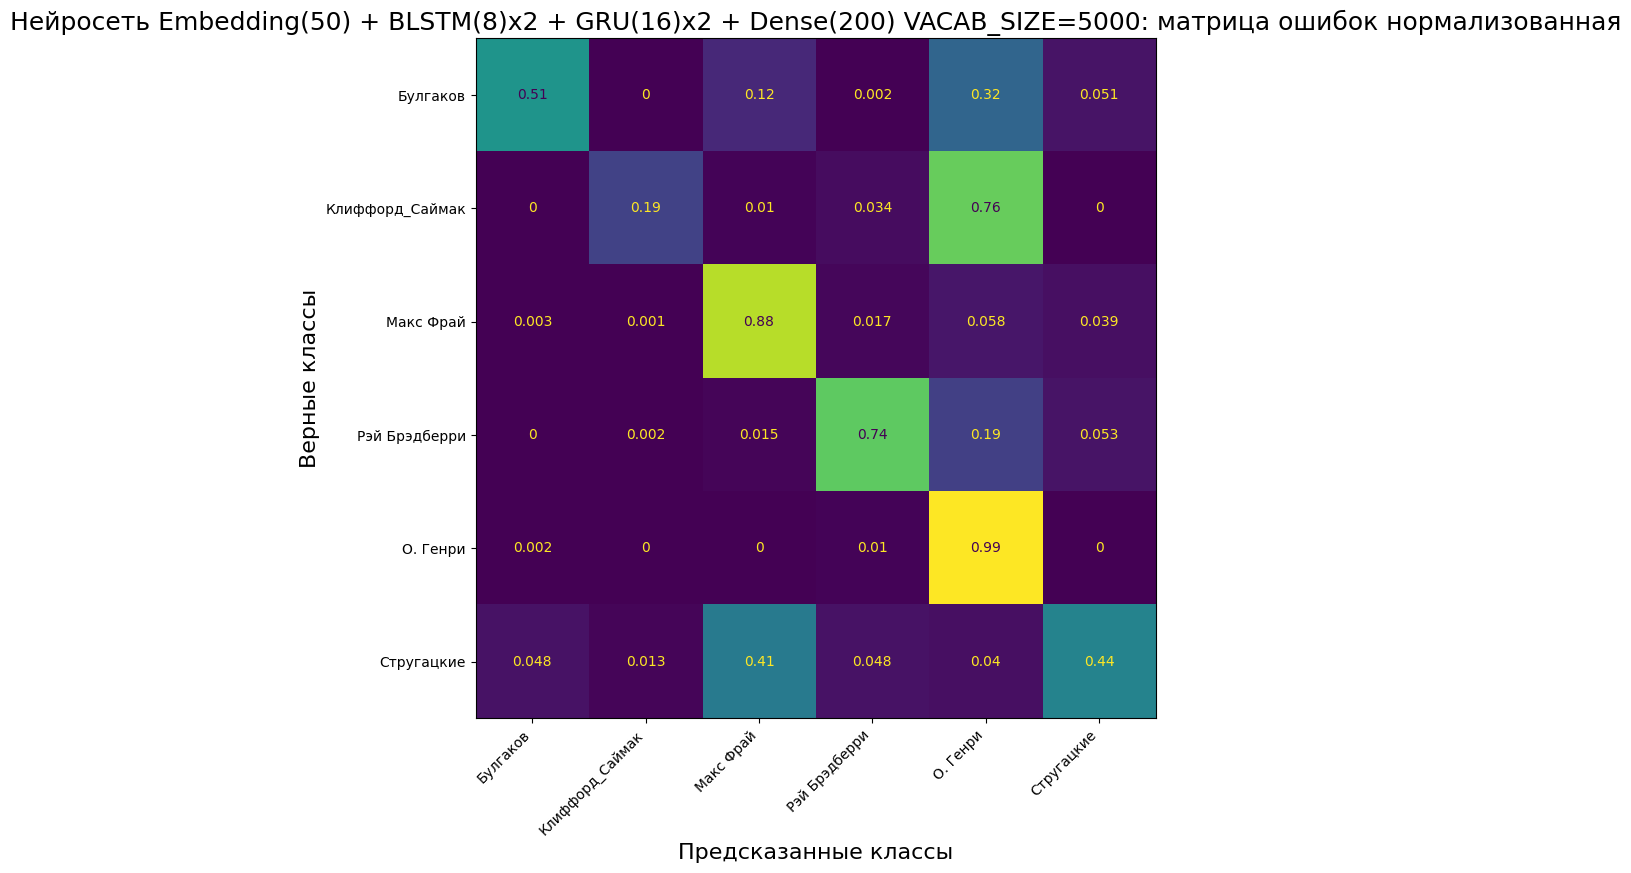

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=5000
Класс: Булгаков              51% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       76% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Макс Фрай             88% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         74% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: О. Генри              99% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Стругацкие            44% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  63%
(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_2                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_4 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_5 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

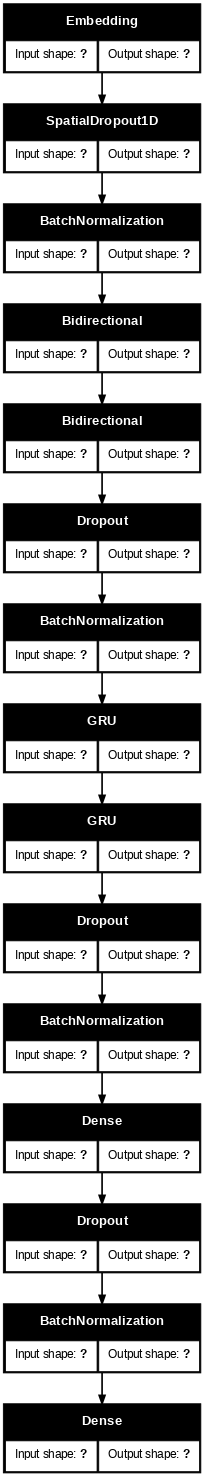

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 0.2105 - loss: 2.1275 - val_accuracy: 0.2929 - val_loss: 1.7288
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.3005 - loss: 1.8373 - val_accuracy: 0.2929 - val_loss: 1.7361
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.3903 - loss: 1.6096 - val_accuracy: 0.3069 - val_loss: 1.7538
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.4730 - loss: 1.3604 - val_accuracy: 0.3210 - val_loss: 1.6914
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.5608 - loss: 1.1352 - val_accuracy: 0.1638 - val_loss: 1.8637
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - accuracy: 0.5930 - loss: 1.0566 - val_accuracy: 0.1716 - val_loss: 1.9822
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step - accuracy: 0.6012 - loss: 1.0479 - val_accuracy: 0.2290 - val_loss: 1.9531
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.6815 - loss: 0.8259 - 

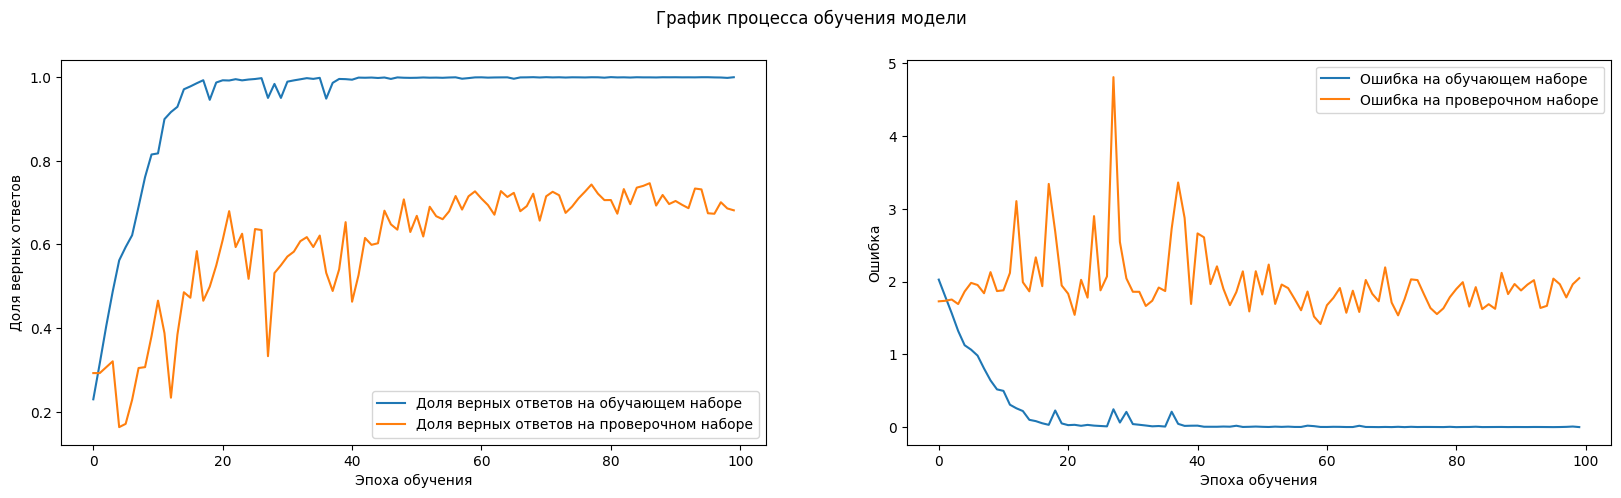

209/209 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step


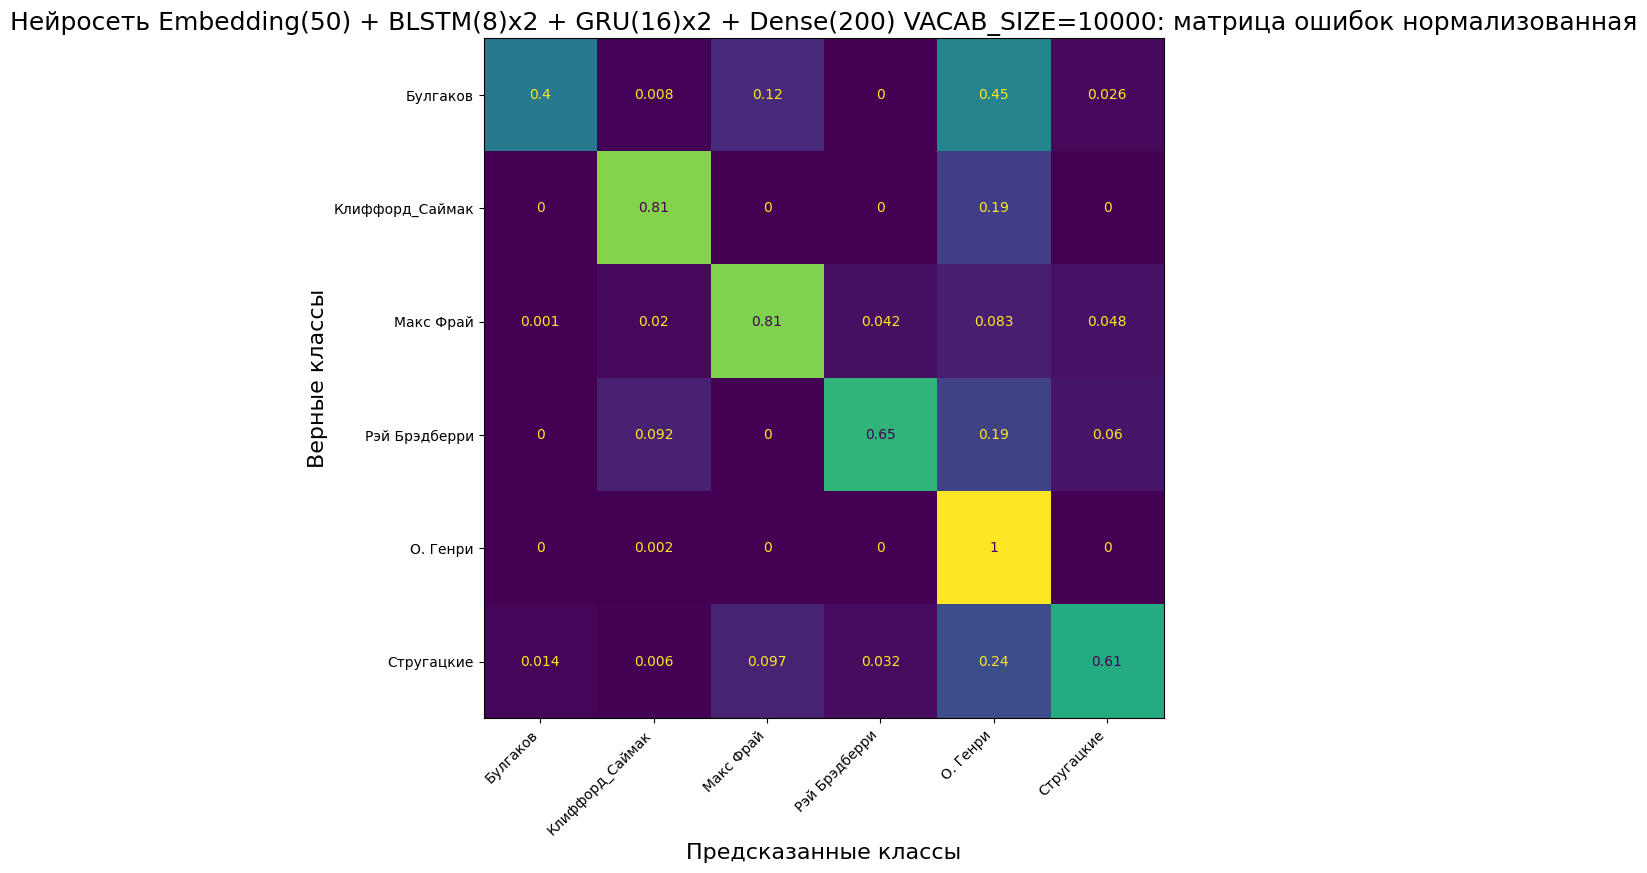

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=10000
Класс: Булгаков              44% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       81% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             81% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         65% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: О. Генри             100% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Стругацкие            61% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  72%
(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_3                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_6 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_7 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_6 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_7 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

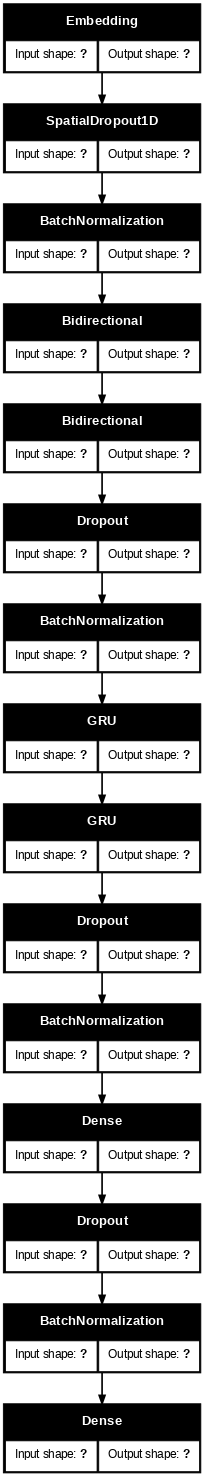

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 303ms/step - accuracy: 0.1966 - loss: 2.1726 - val_accuracy: 0.2929 - val_loss: 1.7389
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 273ms/step - accuracy: 0.3412 - loss: 1.7321 - val_accuracy: 0.1611 - val_loss: 1.7759
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.4481 - loss: 1.3662 - val_accuracy: 0.0866 - val_loss: 1.8849
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.4908 - loss: 1.2254 - val_accuracy: 0.1611 - val_loss: 1.9219
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.4690 - loss: 1.3876 - val_accuracy: 0.1611 - val_loss: 2.0448
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.5851 - loss: 1.0509 - val_accuracy: 0.1611 - val_loss: 2.2037
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.6353 - loss: 0.9282 - val_accuracy: 0.1614 - val_loss: 2.4737
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.6980 - loss: 0.7586 - 

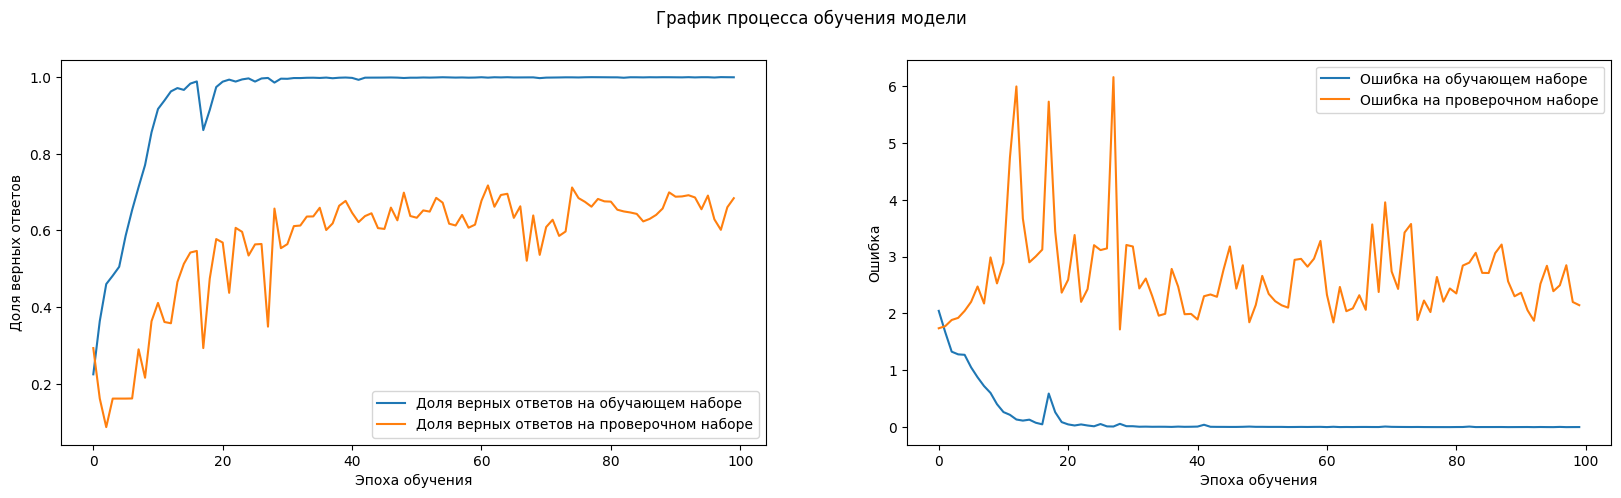

209/209 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step


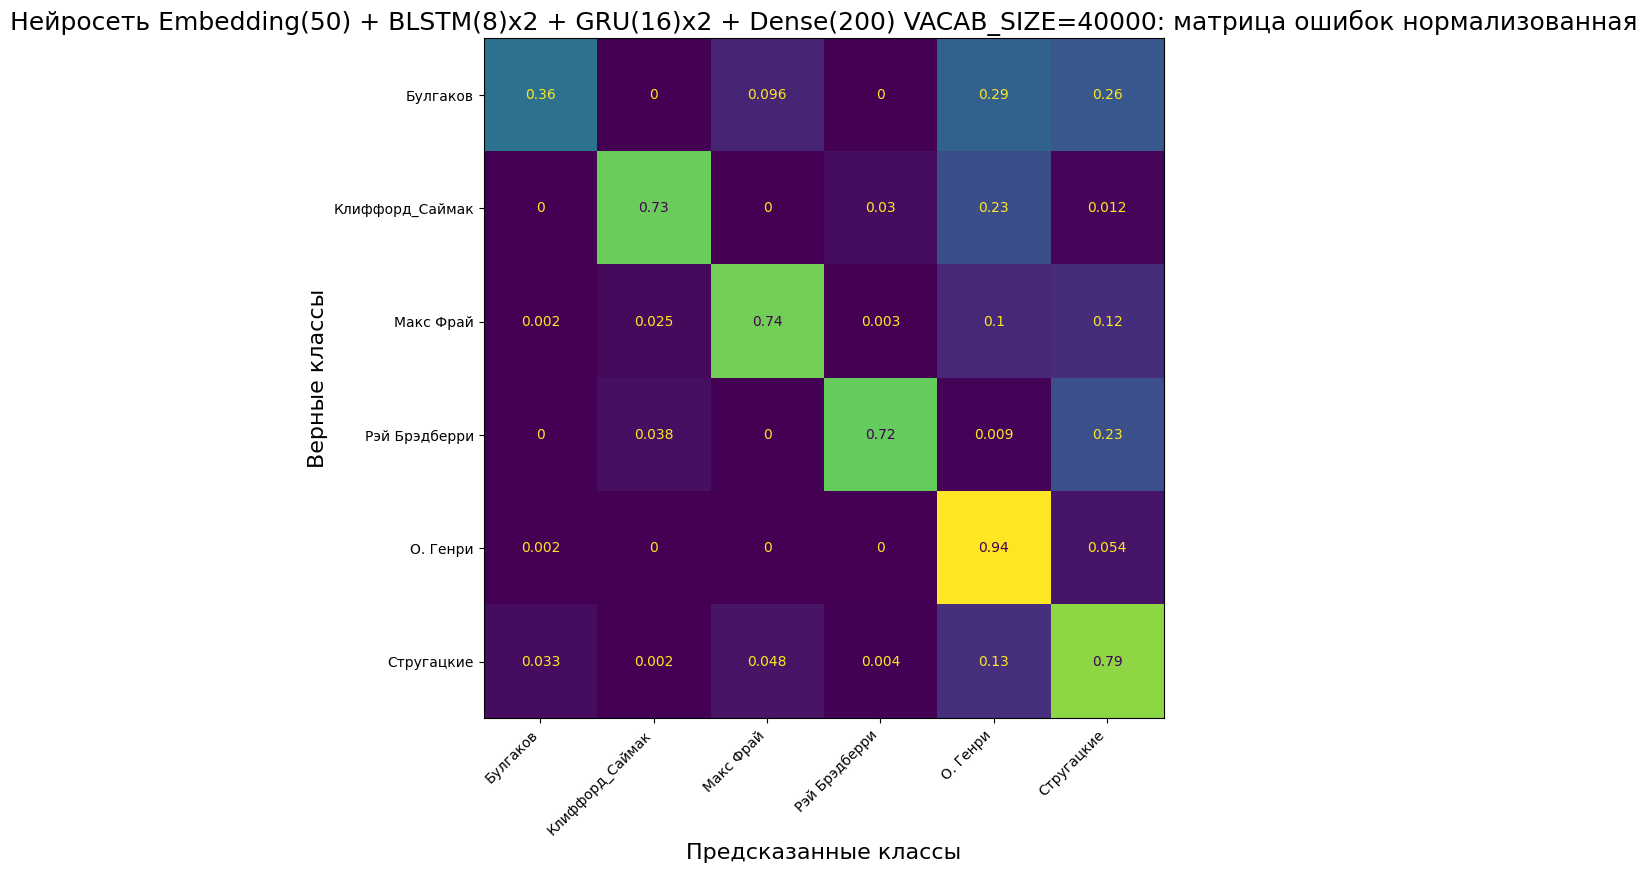

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=40000
Класс: Булгаков              36% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       73% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             74% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         72% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: О. Генри              94% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Стругацкие            79% сеть отнесла к классу Стругацкие           - ВЕРНО :-)

Средняя точность распознавания:  71%


In [18]:
WIN_SIZE   = 1000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 100                          # Шаг окна разбиения текста на векторы
for VOCAB_SIZE in [5000, 10000, 40000]: # Объем словаря для токенизатора
  tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                            lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)
  stat['VOCAB_SIZE'].append(VOCAB_SIZE)
  stat['WIN_SIZE'].append(WIN_SIZE)
  stat['WIN_HOP'].append(WIN_HOP)

  # Построение частотного словаря по обучающим текстам
  tokenizer.fit_on_texts(text_train)
  # Построение словаря в виде пар слово - индекс
  items = list(tokenizer.word_index.items())
  # Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
  seq_train = tokenizer.texts_to_sequences(text_train)
  seq_test = tokenizer.texts_to_sequences(text_test)
 # Формирование обучающей выборки
  x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
  # Формирование тестовой выборки
  x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

  # Проверка формы сформированных данных
  print(x_train.shape, y_train.shape)
  print(x_test.shape, y_test.shape)

  model = Sequential()
  model.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
  model.add(SpatialDropout1D(0.4))
  model.add(BatchNormalization())
  # Два двунаправленных рекуррентных слоя LSTM
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Два рекуррентных слоя GRU
  model.add(GRU(16, return_sequences=True, reset_after=True))
  model.add(GRU(16, reset_after=True))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Дополнительный полносвязный слой
  model.add(Dense(200, activation='relu'))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  model.add(Dense(CLASS_COUNT, activation='softmax'))
  model.build()
  compile_train_eval_model(model,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=' + str(VOCAB_SIZE))





In [21]:
stat
df = pd.DataFrame(stat)
df


,Title,VOCAB_SIZE,WIN_SIZE,WIN_HOP,avg_accuracy
0,Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense...,20000,1000,100,57.050000
1,Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense...,5000,1000,100,62.683333
2,Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense...,10000,1000,100,71.500000
3,Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense...,40000,1000,100,71.350000


(35336, 500) (35336, 6)
(13427, 500) (13427, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_4                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_9 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_8 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_9 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

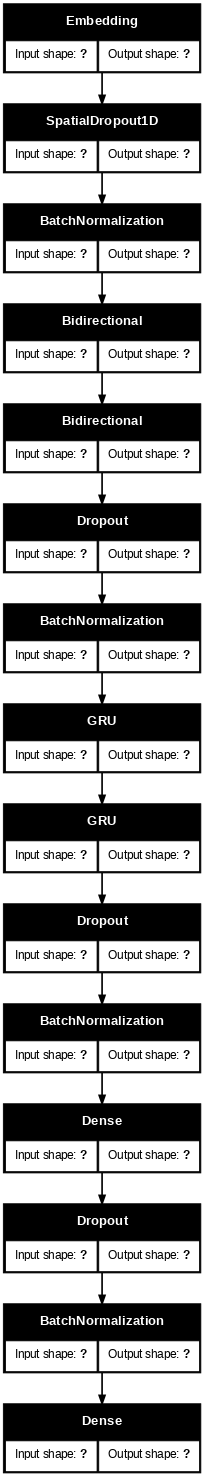

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.2286 - loss: 2.0835 - val_accuracy: 0.2923 - val_loss: 1.7416
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 147ms/step - accuracy: 0.4441 - loss: 1.4522 - val_accuracy: 0.1611 - val_loss: 1.8555
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.6164 - loss: 0.9691 - val_accuracy: 0.2952 - val_loss: 1.8865
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.6532 - loss: 0.8815 - val_accuracy: 0.2000 - val_loss: 2.1555
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - accuracy: 0.7376 - loss: 0.6844 - val_accuracy: 0.3144 - val_loss: 2.5612
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 162ms/step - accuracy: 0.8107 - loss: 0.5170 - val_accuracy: 0.3683 - val_loss: 3.0155
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 144ms/step - accuracy: 0.8759 - loss: 0.3840 - val_accuracy: 0.4155 - val_loss: 3.2593
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.9359 - loss: 0.2434 - 

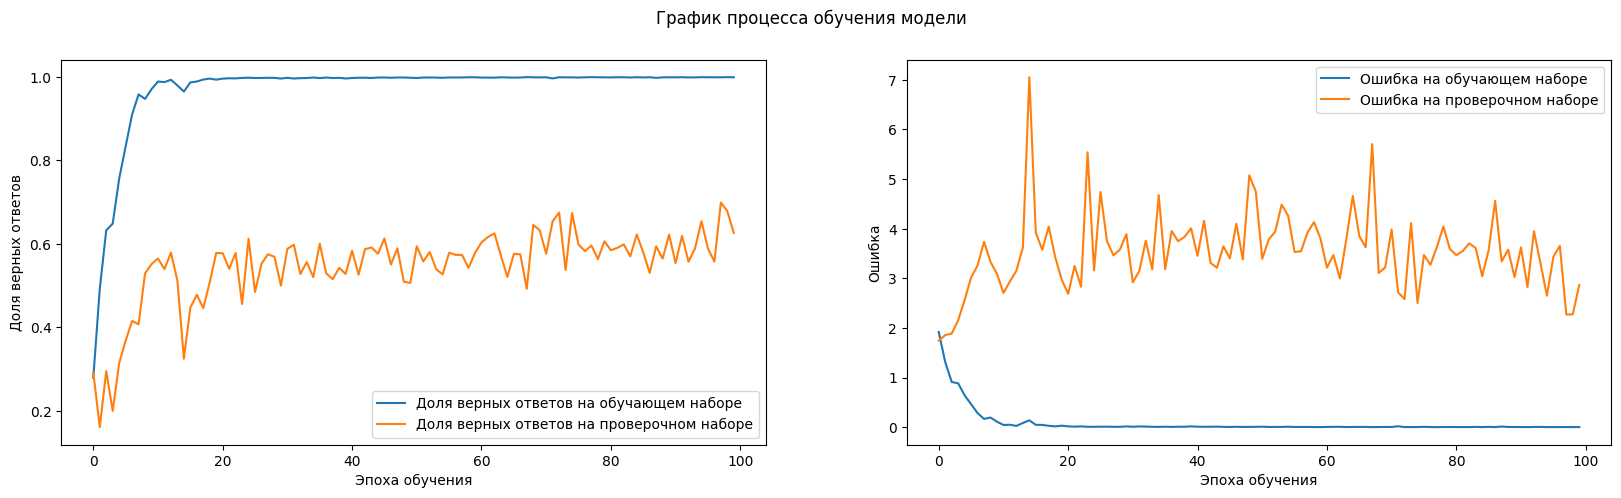

420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step


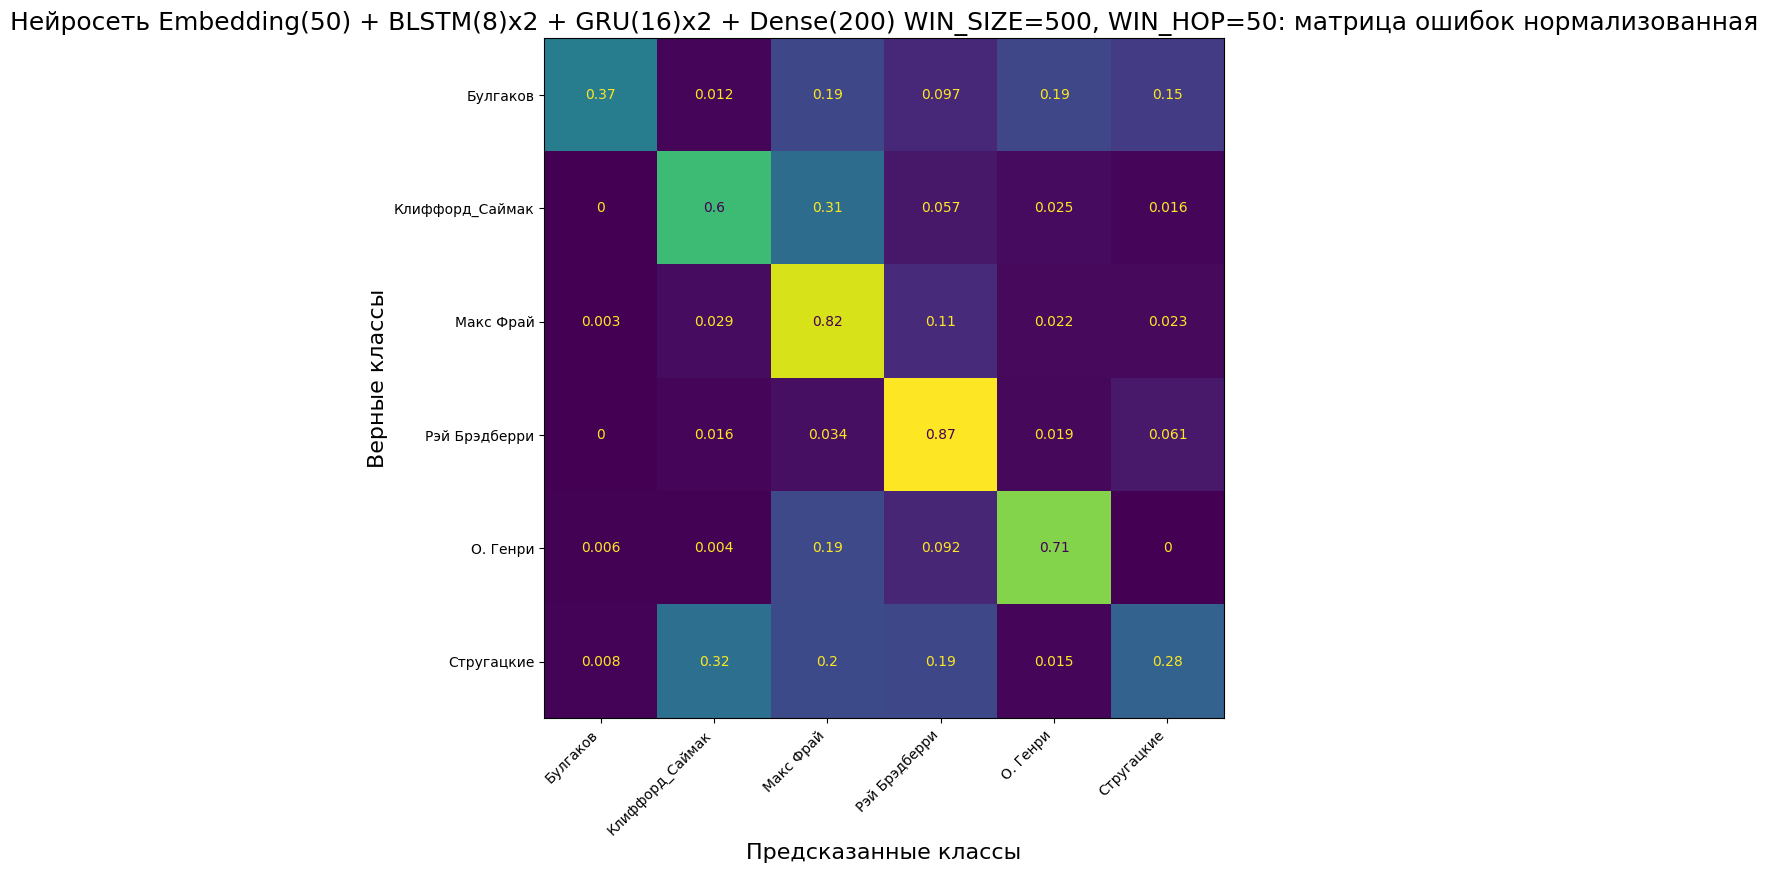

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) WIN_SIZE=500, WIN_HOP=50
Класс: Булгаков              37% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       60% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Макс Фрай             82% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Рэй Брэдберри         87% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: О. Генри              71% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Стругацкие            32% сеть отнесла к классу Клиффорд_Саймак      - НЕВЕРНО :-(

Средняя точность распознавания:  61%
(8792, 2000) (8792, 6)
(3314, 2000) (3314, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_5                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_10 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_11 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_10 (GRU)                         │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_11 (GRU)                         │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

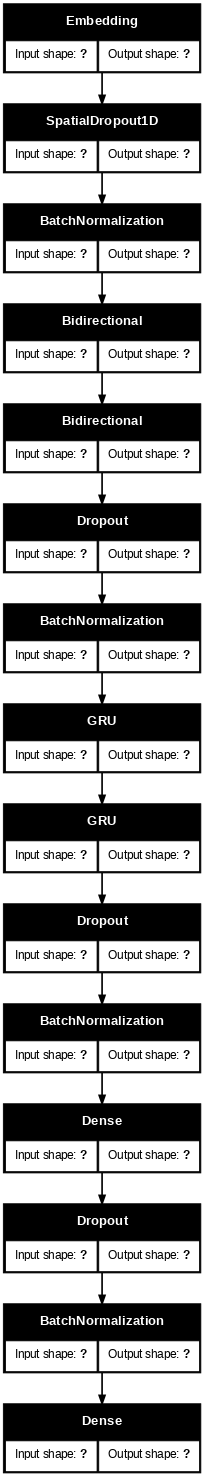

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 580ms/step - accuracy: 0.1891 - loss: 2.2173 - val_accuracy: 0.2939 - val_loss: 1.7482
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 601ms/step - accuracy: 0.2418 - loss: 1.9608 - val_accuracy: 0.2939 - val_loss: 1.7376
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 518ms/step - accuracy: 0.3009 - loss: 1.8255 - val_accuracy: 0.2939 - val_loss: 1.7375
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 520ms/step - accuracy: 0.3670 - loss: 1.6566 - val_accuracy: 0.2939 - val_loss: 1.7442
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 519ms/step - accuracy: 0.4401 - loss: 1.4620 - val_accuracy: 0.2867 - val_loss: 1.7686
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 520ms/step - accuracy: 0.4753 - loss: 1.3386 - val_accuracy: 0.1862 - val_loss: 1.7918
Epoch 7/100
 5/18 ━━━━━━━━━━━━━━━━━━━━ 5s 455ms/step - accuracy: 0.5421 - loss: 1.1509

In [ ]:
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
for WIN_SIZE,WIN_HOP in ((500, 50), (2000, 200)):
  tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                            lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)
  stat['VOCAB_SIZE'].append(VOCAB_SIZE)
  stat['WIN_SIZE'].append(WIN_SIZE)
  stat['WIN_HOP'].append(WIN_HOP)
  # Построение частотного словаря по обучающим текстам
  tokenizer.fit_on_texts(text_train)
  # Построение словаря в виде пар слово - индекс
  items = list(tokenizer.word_index.items())
  # Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
  seq_train = tokenizer.texts_to_sequences(text_train)
  seq_test = tokenizer.texts_to_sequences(text_test)
 # Формирование обучающей выборки
  x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
  # Формирование тестовой выборки
  x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

  # Проверка формы сформированных данных
  print(x_train.shape, y_train.shape)
  print(x_test.shape, y_test.shape)

  model = Sequential()
  model.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
  model.add(SpatialDropout1D(0.4))
  model.add(BatchNormalization())
  # Два двунаправленных рекуррентных слоя LSTM
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Два рекуррентных слоя GRU
  model.add(GRU(16, return_sequences=True, reset_after=True))
  model.add(GRU(16, reset_after=True))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Дополнительный полносвязный слой
  model.add(Dense(200, activation='relu'))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  model.add(Dense(CLASS_COUNT, activation='softmax'))
  model.build()
  compile_train_eval_model(model,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title=f'Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) WIN_SIZE={WIN_SIZE}, WIN_HOP={WIN_HOP}')